# HW3 — Linear Bandits

**Course:** ID6002W Online and Reinforcement Learning (IIT Madras WSAI web-enabled M.Tech)

**Deadline:** Friday, 26 June 2026, 11:59 PM.

**Marks:** 10 (Tasks 1-4: 2 + 2 + 3 + 3 marks), plus an optional bonus.


## About this homework

This homework covers **linear bandits** from Lectures 7-10: LinUCB (Lecture 9), Linear Thompson Sampling (Lecture 9), and what changes when the set of arms varies from round to round (Lecture 10).

The structure is the same as HW1 and HW2. In each part you:

1. **Implement** the core of an algorithm in a `# TODO` cell. You do this twice in this homework: once for LinUCB, once for LinTS.
2. **Run** the pre-filled experiment and plotting cells.
3. **Comment** on what you see in a short write-up cell.

Your code is needed to produce the plots, but **marks are awarded for the written observations** -- your interpretation of what the plots show and why. The marks for each part are stated in its heading. All plotting and experiment scaffolding is provided.

A third algorithm, vanilla UCB, is provided in full. You already wrote it in HW2; here it is only a baseline to compare LinUCB against.

**A note on runtime.** Several cells run experiments at $T = 20000$ over 30-50 seeds; on a typical laptop this can take a few minutes per cell. If you are short on time during a first pass, reduce $T$ to $5000$ and `n_seeds` to $10$ to see the qualitative shape of every plot quickly, then restore the full values before producing the figures you submit.


## Provided codebase

The next cells provide imports, two bandit environments, plotting helpers, and `run_experiment`. Run them once, then start Task 1.

There are two environments. `LinearBandit` has a fixed set of arms (Tasks 1-3). `VaryingLinearBandit` draws a fresh pool of arms every round (Task 4). They share one interface, so the same algorithm code runs on either:

* `env.new_round()` returns the `(K, d)` matrix of feature vectors available this round,
* `env.pull(i)` returns a noisy reward for the `i`-th available arm,
* `env.instantaneous_regret(i)` returns its expected regret,

together with `env.K`, `env.d`, and the noise scale `env.sigma`. The run loop calls `new_round()` for you at the start of each round.


In [1]:
# === Setup: imports and plotting style ===

import numpy as np                  # numerical arrays + random number generators
import matplotlib.pyplot as plt     # plotting
from functools import partial       # used to "bind" hyperparameters (e.g. beta) into algorithms

%matplotlib inline

# A few plot defaults so figures look consistent across the notebook.
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Fixed starting seed for reproducibility (same convention as HW1/HW2).
BASE_SEED = 20260516


def unit_rows(rng, n, d):
    """Return an (n, d) array whose rows are unit-norm vectors, drawn uniformly
    on the sphere in R^d (sample Gaussian, then normalise each row).

    We put arms and theta on the unit sphere throughout, following the
    convention used in Lecture 9 and in Lattimore & Szepesvari.
    """
    G = rng.standard_normal((n, d))
    return G / np.linalg.norm(G, axis=1, keepdims=True)


In [2]:
# === Provided: LinearBandit environment (fixed arms) ===

class LinearBandit:
    """Fixed-arm linear bandit. The mean reward of arm i is <theta, x_i>.

    Parameters
    ----------
    theta : (d,) float        unknown parameter vector. The environment knows it
                              (to generate rewards and regret); the algorithm does not.
    arms  : (K, d) float      feature vector of each arm, fixed for all rounds.
    sigma : float             standard deviation of the Gaussian reward noise.
    rng   : np.random.Generator

    The arm set does not change between rounds, so new_round() always returns the
    same matrix. This keeps a single common interface with VaryingLinearBandit.

    Attributes
    ----------
    d, K        : dimension and number of arms.
    means       : (K,) expected reward per arm, arms @ theta.
    best_mean   : max of means (used for regret).
    best_arm    : argmax of means.
    """

    def __init__(self, theta, arms, sigma, rng):
        self.theta = np.asarray(theta, dtype=float)
        self.arms = np.asarray(arms, dtype=float)
        self.d = self.arms.shape[1]
        self.K = self.arms.shape[0]
        self.sigma = float(sigma)
        self.rng = rng

        # Expected reward of each arm, and the best arm -- used for regret.
        self.means = self.arms @ self.theta
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))

    def new_round(self):
        """Return the (K, d) feature matrix available this round (constant here)."""
        return self.arms

    def pull(self, i):
        """Pull the i-th available arm; return a noisy reward <theta, x_i> + noise."""
        return float(self.means[i] + self.sigma * self.rng.standard_normal())

    def instantaneous_regret(self, i):
        """Expected regret of pulling arm i: best_mean - mean_i."""
        return self.best_mean - float(self.means[i])


In [3]:
# === Provided: VaryingLinearBandit environment (fresh pool each round) ===

class VaryingLinearBandit:
    """Time-varying linear bandit. The same theta throughout, but a fresh pool of
    K arms is drawn every round -- the "churning article pool" of Task 4.

    Each round, new_round() samples K unit-norm feature vectors and stores them.
    pull() and instantaneous_regret() refer to that stored pool, so they are only
    valid after new_round() has been called for the current round. The run loop
    does this for you.

    Parameters
    ----------
    theta : (d,) float
    K     : int               pool size each round
    sigma : float
    rng   : np.random.Generator
    """

    def __init__(self, theta, K, sigma, rng):
        self.theta = np.asarray(theta, dtype=float)
        self.d = self.theta.shape[0]
        self.K = int(K)
        self.sigma = float(sigma)
        self.rng = rng
        self._X = None          # current round's (K, d) feature matrix
        self._means = None      # current round's (K,) expected rewards

    def new_round(self):
        """Draw and store a fresh pool of arms; return the (K, d) matrix."""
        G = self.rng.standard_normal((self.K, self.d))
        self._X = G / np.linalg.norm(G, axis=1, keepdims=True)
        self._means = self._X @ self.theta
        return self._X

    def pull(self, i):
        return float(self._means[i] + self.sigma * self.rng.standard_normal())

    def instantaneous_regret(self, i):
        """Regret against the best arm available this round."""
        return float(self._means.max() - self._means[i])


In [4]:
# === Provided: plotting helpers ===

def plot_averaged_regret(regret_matrix, label, ax, with_band=True):
    """Mean cumulative regret across seeds, with an optional +/- 1 std band.

    regret_matrix : (n_seeds, T) instantaneous regret per round per seed.
    """
    cum = np.cumsum(regret_matrix, axis=1)             # (n_seeds, T) cumulative
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)
    t = np.arange(1, cum.shape[1] + 1)
    line, = ax.plot(t, mean, label=label)
    if with_band:
        # Shaded band = variability across seeds. When the per-seed regret is
        # right-skewed (a few unlucky runs with very large regret), the band can
        # reach below zero -- that is a faithful representation of the spread,
        # not a bug. You will see this most clearly in Task 3B.
        ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret  (mean +/- 1 std)")
    ax.legend()


def plot_regret_seedspread(regret_matrix, ax, color, label, mean_lw=2.5):
    """Every seed as a faded line, plus a thick mean line. This is the Lecture 9
    style; use it when the *spread across seeds* is the point of the plot.

    regret_matrix : (n_seeds, T).
    """
    cum = np.cumsum(regret_matrix, axis=1)
    t = np.arange(1, cum.shape[1] + 1)
    for row in cum:
        ax.plot(t, row, color=color, alpha=0.12, lw=0.8)   # one faded line per seed
    ax.plot(t, cum.mean(axis=0), color=color, lw=mean_lw, label=label)
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret")
    ax.legend()


def draw_confidence_ellipse(ax, theta_hat, V, beta, **kwargs):
    """Draw the boundary of the 2-D confidence ellipsoid
        { theta : (theta - theta_hat)^T V (theta - theta_hat) <= beta^2 }.

    The set is an ellipse centred at theta_hat. Writing theta - theta_hat in the
    eigenbasis of V, the boundary has semi-axis length beta / sqrt(eigenvalue)
    along each eigenvector. As V grows (more data) the eigenvalues grow and the
    ellipse shrinks. Used by the Task 2 / Task 3 ellipsoid plots.
    """
    vals, vecs = np.linalg.eigh(V)                      # V is symmetric PSD
    angles = np.linspace(0, 2 * np.pi, 200)
    circle = np.stack([np.cos(angles), np.sin(angles)])        # (2, 200) unit circle
    radii = beta / np.sqrt(vals)                               # semi-axis lengths
    ellipse = vecs @ (radii[:, None] * circle) + theta_hat[:, None]
    ax.plot(ellipse[0], ellipse[1], **kwargs)


In [5]:
# === Provided: run_experiment helper ===

def run_experiment(algo_fn, env_factory, T, n_seeds, base_seed=BASE_SEED):
    """Run algo_fn for n_seeds independent seeds on envs built by env_factory.

    Parameters
    ----------
    algo_fn : callable    algo_fn(env, T) -> (arm_sequence, regret_sequence).
                          Bind extra params (e.g. beta) with functools.partial.
    env_factory : callable    env_factory(rng) -> a linear bandit environment.
                          Builds a fresh env per seed, so each seed sees an
                          independent stream of rewards (and, for the varying
                          environment, an independent stream of arm pools).
    T : int               Horizon.
    n_seeds : int         Number of independent runs to average over.
    base_seed : int       Seeds used are base_seed + 0, base_seed + 1, ...

    Returns
    -------
    regret_matrix : (n_seeds, T) float array of instantaneous regrets.
    arm_matrix    : (n_seeds, T) int   array of arms pulled.
    """
    regret_matrix = np.zeros((n_seeds, T))
    arm_matrix = np.zeros((n_seeds, T), dtype=int)
    for s in range(n_seeds):
        rng = np.random.default_rng(base_seed + s)
        env = env_factory(rng)
        arms, regrets = algo_fn(env, T)
        regret_matrix[s] = regrets
        arm_matrix[s] = arms
    return regret_matrix, arm_matrix


---

## Task 1 -- Vanilla UCB vs LinUCB on fixed arms (2 marks)

In a linear bandit the mean reward of arm $i$ is $\mu_i = \langle \theta, x_i\rangle$, where $\theta \in \mathbb{R}^d$ is unknown and the feature vector $x_i \in \mathbb{R}^d$ is known. Vanilla UCB ignores the features: it treats the $K$ arms as $K$ unrelated problems and must try each one many times. LinUCB uses the features: every pull updates a single shared estimate $\hat\theta$, so one pull is informative about *all* arms. When $K$ is much larger than $d$, this is the difference between learning $K$ numbers and learning $d$ numbers.

You will implement LinUCB once, then use it here and in Tasks 2 and 4.

Recall the algorithm from Lecture 9. Maintain
$$ V_t = \lambda I + \sum_{s\le t} x_{(s)} x_{(s)}^\top, \qquad b_t = \sum_{s \le t} x_{(s)} y_{(s)}, \qquad \hat\theta_t = V_t^{-1} b_t, $$
and each round pull the arm with the largest optimistic score
$$ \langle \hat\theta_t, x_i\rangle + \beta\,\lVert x_i\rVert_{V_t^{-1}}, \qquad \lVert x\rVert_{V^{-1}} = \sqrt{x^\top V^{-1} x}. $$

* **A** -- regret over time, fixed arms *(1 mark)*
* **B** -- how regret scales with the number of arms $K$ *(1 mark)*


In [6]:
# === Provided: vanilla UCB (treats each fixed arm independently) ===
#
# UCB for Gaussian rewards, exactly as in HW2 Part D, with one cosmetic change:
# it reads the arms from env.new_round() but uses ONLY their identity, never
# their feature vectors. It therefore treats the K arms as K unrelated problems
# -- the baseline we compare LinUCB against. Provided in full; you do not
# implement it. Valid only on the fixed-arm LinearBandit.

def vanilla_ucb(env, T, c=2.0):
    K = env.K
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)
    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)
    sigma = getattr(env, "sigma", 1.0)
    for t_idx in range(T):
        env.new_round()                      # refresh (no-op for fixed arms); features ignored
        if (counts == 0).any():
            arm = int(np.argmin(counts))     # pull each arm once first
        else:
            means = sum_rewards / counts
            bonus = sigma * np.sqrt(c * np.log(T) / counts)
            arm = int(np.argmax(means + bonus))
        y = env.pull(arm)
        sum_rewards[arm] += y
        counts[arm] += 1
        arm_sequence[t_idx] = arm
        regret_sequence[t_idx] = env.instantaneous_regret(arm)
    return arm_sequence, regret_sequence


In [7]:
# === Task 1: LinUCB implementation ===

def linucb(env, T, beta=1.0, lam=1.0, return_trace=False):
    """LinUCB on a linear bandit environment.

    Each round the environment exposes
        X = env.new_round()           -> (K, d) feature matrix of arms available now
        env.pull(i)                   -> reward y for the i-th available arm
        env.instantaneous_regret(i)   -> expected regret of pulling it
    together with env.K, env.d.

    Following Lecture 9, maintain
        V = lam * I + sum_s x(s) x(s)^T          (d x d)
        b = sum_s x(s) y(s)                       (d,)
        theta_hat = V^{-1} b                      (d,)
    and each round play the arm with the largest optimistic score
        score_i = <theta_hat, x_i> + beta * ||x_i||_{V^{-1}},
    where ||x||_{V^{-1}} = sqrt( x^T V^{-1} x ).

    Parameters
    ----------
    env          : linear bandit (interface above)
    T            : int     horizon
    beta         : float   confidence-ellipsoid radius (exploration knob; Lecture 9 default 1.0)
    lam          : float   ridge parameter in V_0 = lam * I
    return_trace : bool    if True, also return per-round theta_hat and V (for the
                            ellipsoid / error plots). Provided storage; do not touch it.

    Returns
    -------
    arm_sequence    : (T,) int     index of the arm pulled each round
    regret_sequence : (T,) float   instantaneous (expected) regret per round
    trace           : dict         returned ONLY if return_trace=True. Keys "theta_hat"
                                    (T, d) and "V" (T, d, d), recorded each round.
    """
    d = env.d
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    # Sufficient statistics. V starts at lam * I (ridge); b starts at 0.
    V = lam * np.eye(d)
    b = np.zeros(d)

    # Provided: storage for the trace plots. Do not edit.
    if return_trace:
        theta_hist = np.zeros((T, d))
        V_hist = np.zeros((T, d, d))

    for t_idx in range(T):
        X = env.new_round()            # (K, d) features available this round

        # TODO: select the arm `arm` to pull this round.
        #   1. Invert V once: Vinv = np.linalg.inv(V).
        #   2. Current estimate: theta_hat = Vinv @ b.
        #   3. For every available arm i (row X[i]):
        #         mean_i  = X[i] @ theta_hat
        #         bonus_i = beta * sqrt( X[i] @ Vinv @ X[i] )
        #      You can do all arms at once:
        #         means   = X @ theta_hat                              # (K,)
        #         bonuses = beta * np.sqrt(np.sum((X @ Vinv) * X, axis=1))   # (K,)
        #      (a plain loop over arms is also fine.)
        #   4. arm = argmax over i of (mean_i + bonus_i).
        Vinv = np.linalg.inv(V)
        theta_hat = Vinv @ b
        means = X @ theta_hat
        bonuses = beta * np.sqrt(np.sum((X @ Vinv) * X, axis=1))
        arm = np.argmax(means + bonuses)
        
        # Pull the chosen arm, observe reward, record regret. (Provided.)
        x = X[arm]
        y = env.pull(arm)
        arm_sequence[t_idx] = arm
        regret_sequence[t_idx] = env.instantaneous_regret(arm)

        # TODO: update the sufficient statistics with the observation (x, y).
        #   V <- V + np.outer(x, x)
        #   b <- b + y * x
        V = V + np.outer(x, x)
        b = b + y * x
        
        # Provided: record the trace. Do not edit.
        if return_trace:
            theta_hist[t_idx] = np.linalg.inv(V) @ b
            V_hist[t_idx] = V

    if return_trace:
        return arm_sequence, regret_sequence, {"theta_hat": theta_hist, "V": V_hist}
    return arm_sequence, regret_sequence


In [8]:
# === Provided: the shared fixed linear-bandit instance (Tasks 1, 2, 3) ===
# theta and the arm features are fixed across seeds; only the reward noise
# differs between seeds. This mirrors HW2, where the arm means were fixed.

D_FIX, K_FIX = 5, 50
SIGMA = 0.5

_inst_rng = np.random.default_rng(BASE_SEED)
theta_star = unit_rows(_inst_rng, 1, D_FIX)[0]      # true parameter, unit norm
arms_fixed = unit_rows(_inst_rng, K_FIX, D_FIX)     # K fixed arms, unit norm

def env_factory_fixed(rng):
    """Build the shared fixed instance with a fresh reward RNG (one per seed)."""
    return LinearBandit(theta_star, arms_fixed, sigma=SIGMA, rng=rng)


### Part A -- regret over time *(1 mark)*

A single fixed instance with $d = 5$ and $K = 50$ (so $K \gg d$). We run vanilla UCB and LinUCB on it and plot cumulative regret, averaged over seeds.


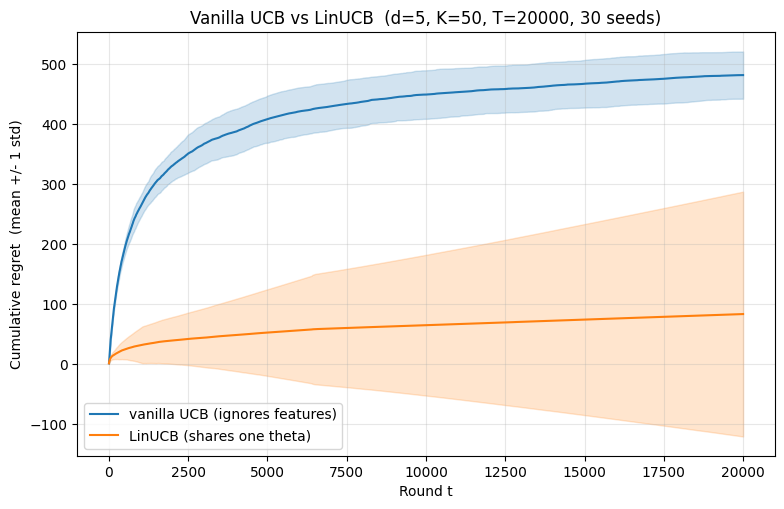

In [9]:
# === Task 1, Part A: vanilla UCB vs LinUCB on the shared fixed instance ===
T = 20000
n_seeds = 30          # reduce (e.g. to 10) if this is slow on your machine

ucb_reg, _ = run_experiment(vanilla_ucb, env_factory_fixed, T, n_seeds)
lin_reg, _ = run_experiment(linucb, env_factory_fixed, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_averaged_regret(ucb_reg, "vanilla UCB (ignores features)", ax)
plot_averaged_regret(lin_reg, "LinUCB (shares one theta)", ax)
ax.set_title(f"Vanilla UCB vs LinUCB  (d={D_FIX}, K={K_FIX}, T={T}, {n_seeds} seeds)")
plt.show()


**Write-up (TODO) -- 1 mark.**

Compare the two curves. Vanilla UCB's regret keeps climbing because it must rule out each of the $K$ arms individually; LinUCB's bends over much sooner. Explain, in terms of *what each algorithm has to learn*, why sharing one $\theta$ across arms produces this gap. Roughly how many rounds does each spend before its regret curve flattens?

*(TODO: write your observations below.)*


**Observations**: 
* Linear UCB benefits from the correct assumption that the arms are related, i.e. pulling one arm enables it to learn shared environment vector that affects all arms. So it learns much faster than vanilla UCB (which assumes K independent arms and has to eliminate them one by one). 
* Vanilla UCB spends around 5000 rounds before its curve starts to bend and flatten, whereas this only takes a few hundred rounds for Linear UCB.

### Part B -- scaling with the number of arms *(1 mark)*

The same kind of instance, but now we vary $K$ over $\{5, 10, 20, 50, 100\}$ at fixed $d = 5$ and record the **final** cumulative regret of each algorithm. We report the **median** over seeds: a few unlucky runs of LinUCB can have very large regret (you will see this directly in Task 3B), and the median is the typical run, robust to those outliers. This is the "regret vs number of arms" plot from Lecture 9, drawn for both algorithms together.


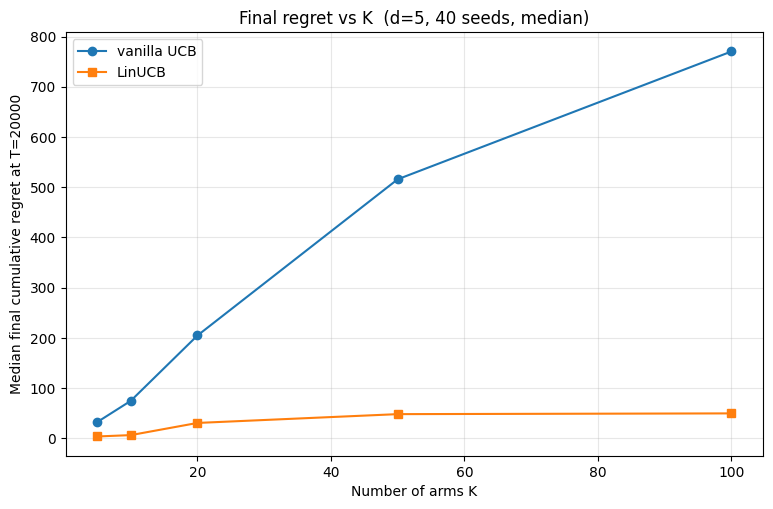

In [10]:
# === Task 1, Part B: final regret vs number of arms K ===
T = 20000
n_seeds = 40

K_list = [5, 10, 20, 50, 100]

ucb_final, lin_final = [], []
for Kx in K_list:
    # A fixed instance at this K (same d), reused across seeds.
    rng_inst = np.random.default_rng(BASE_SEED + 1000 + Kx)
    th = unit_rows(rng_inst, 1, D_FIX)[0]
    armsK = unit_rows(rng_inst, Kx, D_FIX)

    def factory(rng, th=th, armsK=armsK):
        return LinearBandit(th, armsK, sigma=SIGMA, rng=rng)

    ru, _ = run_experiment(vanilla_ucb, factory, T, n_seeds)
    rl, _ = run_experiment(linucb, factory, T, n_seeds)
    # Median final regret across seeds. The median (not the mean) because a few
    # LinUCB runs can lock onto a wrong arm and end with very large regret; the
    # mean is dragged up by those, the median is the typical run.
    ucb_final.append(np.median(ru.cumsum(axis=1)[:, -1]))
    lin_final.append(np.median(rl.cumsum(axis=1)[:, -1]))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(K_list, ucb_final, "o-", label="vanilla UCB")
ax.plot(K_list, lin_final, "s-", label="LinUCB")
ax.set_xlabel("Number of arms K")
ax.set_ylabel(f"Median final cumulative regret at T={T}")
ax.set_title(f"Final regret vs K  (d={D_FIX}, {n_seeds} seeds, median)")
ax.legend()
plt.show()


**Write-up (TODO) -- 1 mark.**

Describe how each algorithm's median final regret grows with $K$. Vanilla UCB's grows steadily with $K$; LinUCB's grows far more slowly once $K$ exceeds $d$. Relate this to the bounds stated in Lecture 9 -- vanilla UCB regret scales with $\sqrt{KT}$, LinUCB with $d\sqrt{T}$ (up to log factors). Which quantity, $K$ or $d$, controls each curve?

*(TODO: write your observations below.)*


**Observations**: Vanilla UCB's median final regret grows steadily with number of arms $K$, whereas Linear UCB becomes almost constant once $K$ exceeds dimension of context vectors $d = 5$ . This matches with theory - vanilla UCB scales with $\sqrt{K T}$ and hence depends on $K$, whereas Linear UCB depends on $d$ not $K$ so it can scale to a large number of arms.

---

## Task 2 -- Inside LinUCB (2 marks)

This task looks at the two moving parts of LinUCB: the confidence ellipsoid that shrinks as data arrives, and the parameter $\beta$ that sets its size.

* **A** -- the shrinking ellipsoid and the estimation error *(1 mark)*
* **B** -- tuning $\beta$: under- and over-exploration *(1 mark)*


### Part A -- the shrinking confidence ellipsoid *(1 mark)*

In $d = 2$ we can draw the confidence set $\mathcal{E}_t = \{\theta : \lVert \theta - \hat\theta_t\rVert_{V_t} \le \beta\}$ directly. We run LinUCB once on a 2-D instance and plot, at a few snapshots, the ellipse $\mathcal{E}_t$ together with the running estimate $\hat\theta_t$ (coloured by time) and the true $\theta$. Alongside it we plot the estimation error $\lVert \hat\theta_t - \theta\rVert_2$ over time.

*A note on $\beta$.* We use $\beta = 1$ here for visualization, the value used throughout Tasks 1-3. This is not a rigorously calibrated 95% confidence set; the true theoretical $\beta$ that guarantees coverage grows slowly with $t$ (see Lecture 9). So do not be alarmed if the true $\theta$ sometimes lies just outside an ellipse, especially at early $t$.


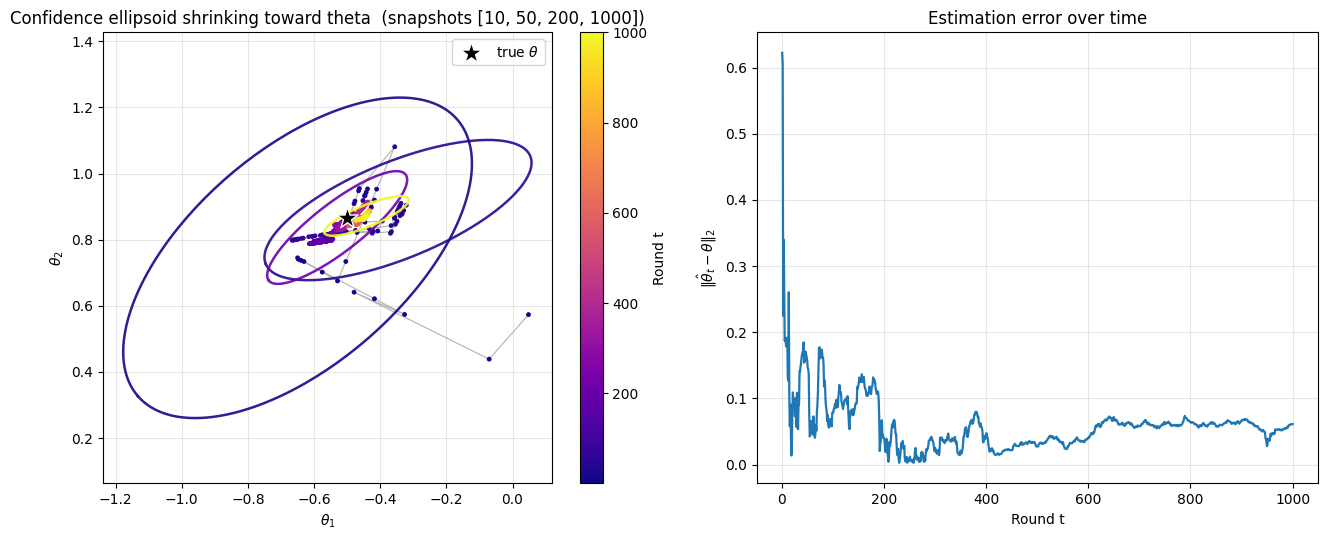

In [11]:
# === Task 2, Part A: shrinking ellipsoid (d=2) and estimation error ===
T_ell = 1000
d2, K2 = 2, 20

# A 2-D instance. theta2 / arms2 are reused by Task 3 Part B, so we fix them here.
inst_rng = np.random.default_rng(BASE_SEED)
theta2 = unit_rows(inst_rng, 1, d2)[0]
arms2 = unit_rows(inst_rng, K2, d2)

env2 = LinearBandit(theta2, arms2, sigma=0.5, rng=np.random.default_rng(BASE_SEED + 1))
_, _, trace2 = linucb(env2, T_ell, beta=1.0, return_trace=True)
theta_hist = trace2["theta_hat"]
V_hist = trace2["V"]

snaps = [10, 50, 200, 1000]            # rounds at which to draw the ellipse
cmap = plt.cm.plasma
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left panel: estimate trajectory (coloured by time) + ellipses at snapshots.
axL = axes[0]
tt = np.arange(1, T_ell + 1)
axL.plot(theta_hist[:, 0], theta_hist[:, 1], color="gray", lw=0.8, alpha=0.6, zorder=1)
sc = axL.scatter(theta_hist[:, 0], theta_hist[:, 1], c=tt, cmap=cmap, s=6, zorder=2)
for s in snaps:
    col = cmap((s - 1) / (T_ell - 1))
    draw_confidence_ellipse(axL, theta_hist[s - 1], V_hist[s - 1], beta=1.0,
                            color=col, lw=1.8, alpha=0.9)
axL.scatter([theta2[0]], [theta2[1]], marker="*", s=260, color="black",
            edgecolor="white", zorder=5, label=r"true $\theta$")
axL.set_xlabel(r"$\theta_1$")
axL.set_ylabel(r"$\theta_2$")
axL.set_title(f"Confidence ellipsoid shrinking toward theta  (snapshots {snaps})")
axL.legend(loc="best")
axL.set_aspect("equal", adjustable="datalim")
cb = fig.colorbar(sc, ax=axL)
cb.set_label("Round t")

# Right panel: estimation error over time.
axR = axes[1]
err = np.linalg.norm(theta_hist - theta2, axis=1)
axR.plot(tt, err, color="#1f77b4", lw=1.6)
axR.set_xlabel("Round t")
axR.set_ylabel(r"$\|\hat\theta_t - \theta\|_2$")
axR.set_title("Estimation error over time")

plt.tight_layout()
plt.show()


**Write-up (TODO) -- 1 mark.**

The ellipses shrink as $t$ grows and the estimate $\hat\theta_t$ settles near the true $\theta$. Connect the two panels: the ellipsoid's size in any direction is $\beta / \sqrt{\text{eigenvalue of } V_t}$ along that direction, and $V_t$ grows with every pull. Why does the ellipse shrink *faster in some directions than others*? (Think about which feature directions get pulled often, and what that does to the eigenvalues of $V_t$.) We return to this in Task 4.

*(TODO: write your observations below.)*


**Observations**: 

When features are rarely explored (often due to being highly correlated with others), the sample variance matrix $V_t$ gains little information along those specific axes. Consequently, the corresponding eigenvalues remain small, keeping the confidence ellipsoid's radius wide and slow to shrink along those unsampled directions. Ellipsoid's radius formula along axis $\beta / \sqrt{\text{eigenvalue of } V_t}$ also shows this inverse relationship.

This is because the confidence radius only shrinks along a specific feature's axis when we explicitly pull arms that align with that axis.

### Part B -- tuning $\beta$ *(1 mark)*

$\beta$ sets the width of the confidence ellipsoid, and so the amount of exploration -- the linear-bandit analogue of the constant $c$ in UCB. We sweep $\beta \in \{0.25, 0.5, 1, 2, 4\}$ on the shared $d=5$, $K=50$ instance.

Two panels. The left panel shows averaged cumulative regret over time, as before. The right panel shows **final** cumulative regret per seed, one strip per $\beta$, which exposes the *distribution* of outcomes that the average curve hides. Pay attention to the difference between the mean (red diamond) and the median (black bar) in the right panel.


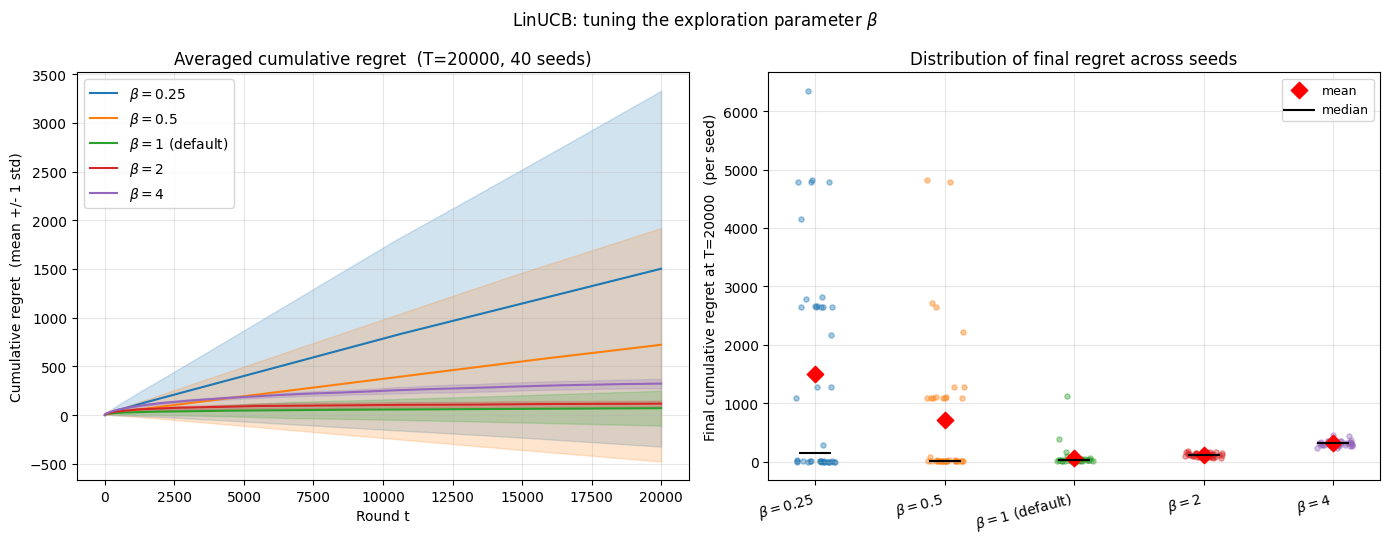

    beta      mean    median       max
    0.25    1502.1     154.9    6346.6
    0.50     721.3      17.0    4822.1
    1.00      70.6      28.7    1118.7
    2.00     117.0     110.8     191.2
    4.00     322.8     320.4     449.8


In [12]:
# === Task 2, Part B: tuning beta ===
T = 20000
n_seeds = 40         # more seeds here than elsewhere: we want the tail of the regret distribution

beta_values = [0.25, 0.5, 1.0, 2.0, 4.0]
beta_labels = {0.25: r"$\beta=0.25$",
               0.5:  r"$\beta=0.5$",
               1.0:  r"$\beta=1$ (default)",
               2.0:  r"$\beta=2$",
               4.0:  r"$\beta=4$"}

# Run all five sweeps once; keep both the cumulative regret matrix (for the time
# plot) and the final per-seed regret (for the strip plot).
cum_by_beta = {}
finals_by_beta = {}
for bval in beta_values:
    algo = partial(linucb, beta=bval)
    reg, _ = run_experiment(algo, env_factory_fixed, T, n_seeds)
    cum_by_beta[bval] = reg
    finals_by_beta[bval] = reg.cumsum(axis=1)[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: averaged cumulative regret over time, one curve per beta.
axL = axes[0]
for bval in beta_values:
    plot_averaged_regret(cum_by_beta[bval], beta_labels[bval], axL)
axL.set_title(f"Averaged cumulative regret  (T={T}, {n_seeds} seeds)")

# Right: final cumulative regret per seed, one strip per beta. The strip plot
# is the same style as Task 3B's: every seed is a faded dot, red diamond is the
# mean, black bar is the median.
axR = axes[1]
positions = np.arange(len(beta_values))
for j, bval in enumerate(beta_values):
    pts = finals_by_beta[bval]
    jit = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.30
    axR.scatter(np.full_like(pts, positions[j], dtype=float) + jit, pts,
                s=14, alpha=0.4)
    axR.scatter([positions[j]], [pts.mean()], color="red", marker="D", s=70,
                zorder=5, label="mean" if j == 0 else None)
    axR.scatter([positions[j]], [np.median(pts)], color="black", marker="_", s=500,
                zorder=5, label="median" if j == 0 else None)
axR.set_xticks(positions)
axR.set_xticklabels([beta_labels[b] for b in beta_values], rotation=15, ha="right")
axR.set_ylabel(f"Final cumulative regret at T={T}  (per seed)")
axR.set_title(r"Distribution of final regret across seeds")
axR.legend(loc="upper right", fontsize=9)

fig.suptitle(r"LinUCB: tuning the exploration parameter $\beta$", fontsize=12)
plt.tight_layout()
plt.show()

# Numerical summary: mean, median, max per beta.
print(f"{'beta':>8}{'mean':>10}{'median':>10}{'max':>10}")
for bval in beta_values:
    f = finals_by_beta[bval]
    print(f"{bval:>8.2f}{f.mean():>10.1f}{np.median(f):>10.1f}{f.max():>10.1f}")


**Write-up (TODO) -- 1 mark.**

Order the five values of $\beta$ by *typical* run (the median in the right panel) and by *worst* run (the top of each strip). These are different orderings.

* Low $\beta$ (under-exploration): why does a value like $\beta = 0.25$ or $0.5$ produce both very-low-regret runs *and* very-high-regret runs in the same strip? What is the algorithm doing on each kind of run, and why can a *deterministic* optimistic rule with too small a bonus get stuck?
* High $\beta$ (over-exploration): why does $\beta = 4$ cluster all its seeds at moderate regret, with no big winners and no catastrophes?
* $\beta = 1$ versus $\beta = 2$: one has a better median, the other has a tighter strip. Which kind of robustness is each one giving you, and which would you prefer in a system you cannot babysit?

*(TODO: write your observations below.)*


**Observations**:
* Orders of $\beta$ by regret in ascending order are:
  * Typical run (median regret): 0.50, 1.00, 2.00, 0.25, 4.00
  * Worst run (maximum regret): 2.00, 4.00, 1.00, 0.50, 0.25
* Low $\beta$ (under-exploration) runs' regret depends on the luck of the environment's randomness during initial arms pulled. It can easily get "locked in" to a bad chosen arm if initially chosen arm was unlucky (i.e. environment gave rewards such that suboptimal arm got more reward). On the other hand it can also get very lucky where best arm gets chosen early.
* High $\beta$ (over-exploration) - each run averages away high and low regret, leading all runs to cluster at moderate regret with no big winners and no catastrophes.
* $\beta = 1$ has a lower median regret but with some outlier runs. If we can run online learning experiment a few times, $\beta = 1$ has a better chance of lower regret in at least one run. But $\beta = 2$ (having slightly higher median regret but no outliers) is preferred overall as we know that for any run (irrespective of environment's randomness), the regret will stay close to its low median regret.

---

## Task 3 -- Linear Thompson Sampling (3 marks)

LinUCB explores by being *optimistic*: it adds a bonus and takes the best case allowed by the confidence ellipsoid. Thompson Sampling explores by being *random*: it draws one plausible parameter from its belief and acts as if that draw were the truth. In the tabular case (HW2) the belief was a Beta posterior per arm; here it is a single Gaussian over $\theta$.

This task introduces LinTS in more detail than the lecture did, because you will implement it now.

**The belief.** With Gaussian noise and a Gaussian prior, Bayesian linear regression gives a Gaussian posterior over $\theta$:
$$ \theta \mid \text{data} \;\sim\; \mathcal{N}\!\left(\hat\theta_t,\; v\, V_t^{-1}\right), $$
with exactly the same $\hat\theta_t$ and $V_t$ that LinUCB already maintains. The scale $v$ controls how wide the belief is (the lecture slides write this scale as $\alpha^2$); Lecture 9 uses $v = \sigma^2 = 0.25$. Like $\beta$ in LinUCB, this knob has a sweet spot (too small and you under-explore, too large and you over-explore); the same kind of curve as Task 2B applies. We hold $v$ fixed in this task. So the centre $\hat\theta_t$ and the shape $V_t^{-1}$ are shared with LinUCB -- the only thing that changes is **how the belief is turned into an action**.

**The rule.** Each round, draw one sample $\tilde\theta \sim \mathcal{N}(\hat\theta_t, v V_t^{-1})$ and pull $\arg\max_i \langle \tilde\theta, x_i\rangle$. A wide belief (early on) produces scattered samples and therefore exploration; as $V_t$ grows the belief narrows, the samples concentrate near $\hat\theta_t$, and LinTS settles on the best arm on its own.

* **A** -- LinTS vs LinUCB: regret *(1 mark)*
* **B** -- the belief concentrating, and a look at run-to-run variability *(2 marks)*


In [13]:
# === Task 3: LinTS implementation ===

def lints(env, T, v=0.25, lam=1.0, return_trace=False):
    """Linear Thompson Sampling on a linear bandit environment.

    LinTS keeps exactly the same sufficient statistics as LinUCB:
        V = lam * I + sum_s x(s) x(s)^T,  b = sum_s x(s) y(s),  theta_hat = V^{-1} b.
    The only change is the arm-selection rule. Instead of adding an optimism bonus,
    LinTS samples one plausible parameter vector from the Gaussian belief
        theta_tilde ~ Normal( theta_hat,  v * V^{-1} )
    and acts greedily under that single sample:
        arm = argmax_i <theta_tilde, x_i>.
    The covariance scale v plays the role of the noise level (Lecture 9 uses v = sigma^2 = 0.25).

    Parameters
    ----------
    env          : linear bandit (same interface as linucb)
    T            : int     horizon
    v            : float   posterior covariance scale (Lecture 9 default sigma^2 = 0.25)
    lam          : float   ridge parameter in V_0 = lam * I
    return_trace : bool    if True, also return per-round theta_hat and V (for the posterior plot).

    Returns
    -------
    arm_sequence, regret_sequence  (and trace if return_trace=True), exactly as in linucb.
    """
    d = env.d
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)
    V = lam * np.eye(d)
    b = np.zeros(d)
    if return_trace:
        theta_hist = np.zeros((T, d))
        V_hist = np.zeros((T, d, d))

    for t_idx in range(T):
        X = env.new_round()

        # TODO: implement one round of Linear Thompson Sampling.
        #   1. Vinv = np.linalg.inv(V);  theta_hat = Vinv @ b.
        #   2. Sample ONE parameter vector from the belief:
        #         theta_tilde = env.rng.multivariate_normal(theta_hat, v * Vinv)
        #      (draws a length-d vector with mean theta_hat and covariance v * V^{-1}.)
        #   3. Score each available arm under this sample: scores = X @ theta_tilde.
        #   4. arm = argmax of those scores.
        Vinv = np.linalg.inv(V)
        theta_hat = Vinv @ b
        theta_tilde = env.rng.multivariate_normal(theta_hat, v * Vinv)
        scores = X @ theta_tilde
        arm = np.argmax(scores)

        x = X[arm]
        y = env.pull(arm)
        arm_sequence[t_idx] = arm
        regret_sequence[t_idx] = env.instantaneous_regret(arm)

        # TODO: update V and b with (x, y), exactly as in LinUCB.
        #   V <- V + np.outer(x, x);  b <- b + y * x
        V = V + np.outer(x, x)
        b = b + y * x
        
        if return_trace:
            theta_hist[t_idx] = np.linalg.inv(V) @ b
            V_hist[t_idx] = V

    if return_trace:
        return arm_sequence, regret_sequence, {"theta_hat": theta_hist, "V": V_hist}
    return arm_sequence, regret_sequence


### Part A -- regret of LinTS vs LinUCB *(1 mark)*

On the shared fixed instance ($d = 5$, $K = 50$), run both algorithms and compare averaged regret.


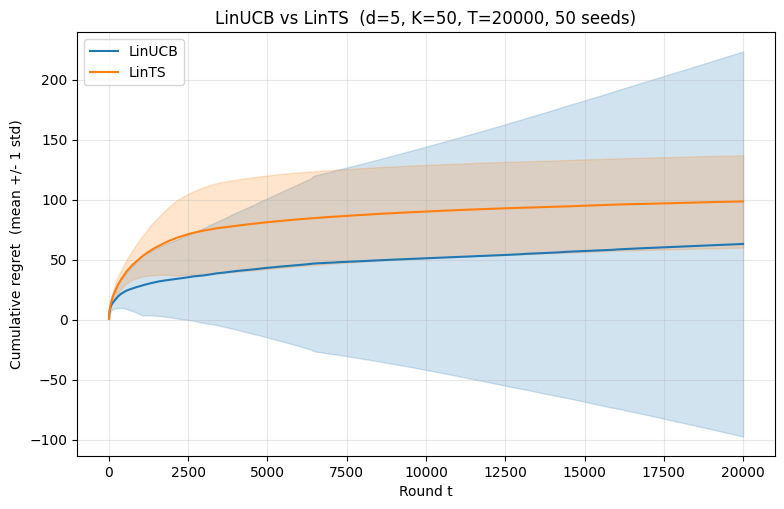

In [14]:
# === Task 3, Part A: LinTS vs LinUCB regret ===
T = 20000
n_seeds = 50          # more seeds here: Part B needs the tail of the regret distribution

lin_reg, _ = run_experiment(linucb, env_factory_fixed, T, n_seeds)
lts_reg, _ = run_experiment(lints, env_factory_fixed, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_averaged_regret(lin_reg, "LinUCB", ax)
plot_averaged_regret(lts_reg, "LinTS", ax)
ax.set_title(f"LinUCB vs LinTS  (d={D_FIX}, K={K_FIX}, T={T}, {n_seeds} seeds)")
plt.show()

# Keep the per-seed final regret for Part B's spread comparison.
linucb_final = lin_reg.cumsum(axis=1)[:, -1]
lints_final = lts_reg.cumsum(axis=1)[:, -1]


**Write-up (TODO) -- 1 mark.**

How do the mean regret curves compare? They should be of the same order; on this instance one may be slightly lower than the other. The more interesting comparison is the width of the two shaded bands ($\pm 1$ std across seeds), which we look at in Part B.

*(TODO: write your observations below.)*


**Observation**: Here LinTS mean regret takes more rounds in its intial phase to flatten regret curve. Other than that LinUCB and LinTS mean regrets are similar. But unlike LinTS, in LinUCB the shaded regret area keeps rapidly expanding with more rounds in a cone shape. So LinTS has similar mean regret but narrower band, whereas LinUCB has larger spread over seeds.

### Part B -- watching exploration become exploitation, and run-to-run variability *(2 marks)*

Two views. First, in $d = 2$ we draw the LinTS belief directly *and* colour the background of $\theta$-space by which arm would be the argmax at each point. The sample cloud is then coloured by which arm each sample would pull. As the belief concentrates, the cloud shrinks; what we want to see is *how* it sits relative to the coloured regions across time. (The cloud has the same shape and orientation as the LinUCB ellipse from Task 2 Part A, since both come from $V_t$.)

Second, we compare the spread of final regret across seeds for the two algorithms.


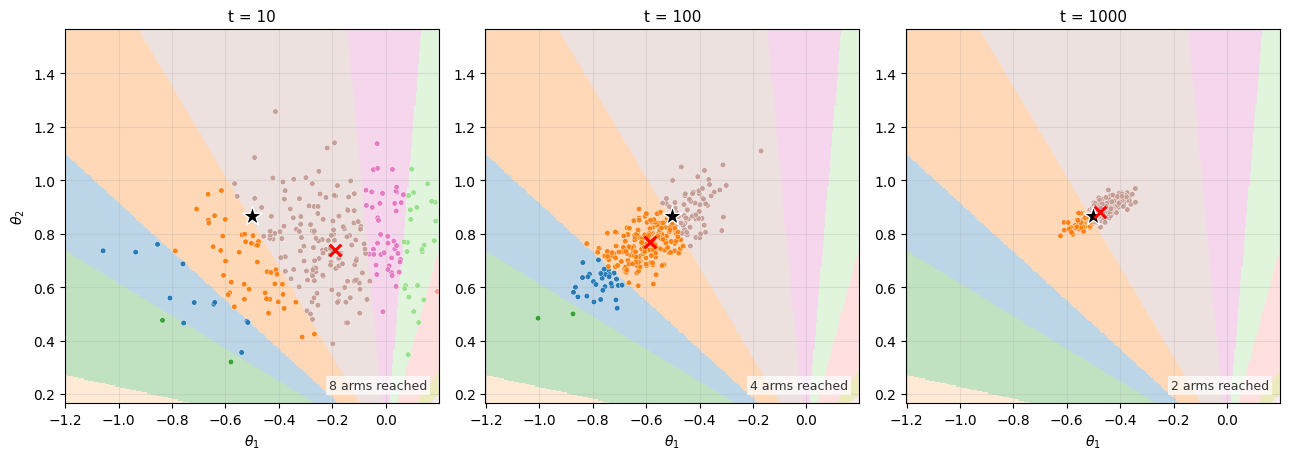

In [15]:
# === Task 3, Part B (i): LinTS samples coloured by which arm they would pull ===
# Reuses the 2-D instance (theta2, arms2) from Task 2 Part A.
# Background colours theta-space by which arm is argmax at each point.
# Samples are coloured the same way, so the colour of each sample is the arm
# LinTS would pull that round.

from matplotlib.colors import ListedColormap

T_dr = 1000
env2b = LinearBandit(theta2, arms2, sigma=0.5, rng=np.random.default_rng(BASE_SEED + 1))
_, _, trace2b = lints(env2b, T_dr, v=0.25, return_trace=True)
th_hist = trace2b["theta_hat"]
V_hist_ts = trace2b["V"]

snaps = [10, 100, 1000]
ALPHA2 = 0.25
N_SAMPLES = 300
N_GRID = 320
K2 = arms2.shape[0]

# Tight square window around theta. WIN=0.7 keeps the t=10 cloud almost entirely
# in view while excluding the origin (where all wedges converge).
WIN = 0.7
xlim = (theta2[0] - WIN, theta2[0] + WIN)
ylim = (theta2[1] - WIN, theta2[1] + WIN)

# The argmax-region map depends only on the arms, so compute it once.
gx = np.linspace(*xlim, N_GRID); gy = np.linspace(*ylim, N_GRID)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.stack([GX.ravel(), GY.ravel()], axis=1)
grid_argmax = np.argmax(grid_pts @ arms2.T, axis=1).reshape(N_GRID, N_GRID)

# tab20 has paired hues; shuffle so adjacent wedges read as clearly different colours.
_perm = np.array([0, 6, 12, 2, 16, 8, 14, 4, 18, 10, 1, 7, 13, 3, 17, 9, 15, 5, 19, 11])
arm_colors = plt.cm.tab20(_perm / 19.0)
bg_cmap = ListedColormap(arm_colors)

sample_rng = np.random.default_rng(BASE_SEED + 999)

fig, axes = plt.subplots(1, len(snaps), figsize=(13, 4.6))
for ax, s in zip(axes, snaps):
    th = th_hist[s - 1]; V = V_hist_ts[s - 1]; Vinv = np.linalg.inv(V)

    # Background: which arm wins at each point of theta-space (low alpha so
    # samples pop on top of it).
    ax.imshow(grid_argmax, origin="lower", extent=(*xlim, *ylim),
              cmap=bg_cmap, vmin=0, vmax=K2 - 1, alpha=0.30,
              interpolation="nearest", aspect="equal")

    # LinTS samples at this snapshot, coloured by which arm each would pull.
    samples = sample_rng.multivariate_normal(th, ALPHA2 * Vinv, size=N_SAMPLES)
    sample_argmax = np.argmax(samples @ arms2.T, axis=1)
    ax.scatter(samples[:, 0], samples[:, 1], c=arm_colors[sample_argmax],
               s=16, edgecolor="white", linewidth=0.3, alpha=0.95, zorder=3)

    # True theta (black star) and current theta_hat (red x).
    ax.scatter([theta2[0]], [theta2[1]], marker="*", s=220, color="black",
               edgecolor="white", linewidth=1.0, zorder=6)
    ax.scatter([th[0]], [th[1]], marker="x", s=70, color="red",
               linewidth=2.2, zorder=6)

    n_arms_hit = len(np.unique(sample_argmax))
    ax.set_title(f"t = {s}", fontsize=11)
    ax.text(0.97, 0.03, f"{n_arms_hit} arms reached",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, color="#333",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=2.0))
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel(r"$\theta_1$")
    if ax is axes[0]:
        ax.set_ylabel(r"$\theta_2$")
plt.tight_layout()
plt.show()

# Note. Black star = true theta. Red x = theta_hat at this snapshot.


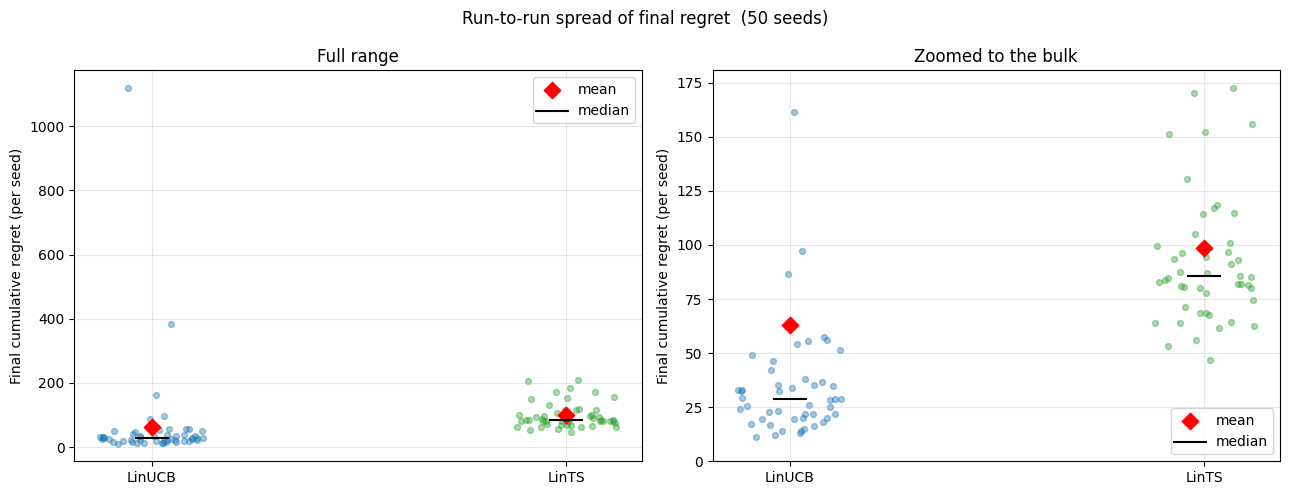

LinUCB final regret: mean=63.2, median=28.7, std=160.5
LinTS  final regret: mean=98.7, median=85.6, std=38.5


In [16]:
# === Task 3, Part B (ii): spread of final regret across seeds ===
# Two panels: the left shows the full range (including any rare high-regret LinUCB
# runs), the right zooms to the bulk so the typical spread is legible. Red diamond
# = mean, black bar = median. For a right-skewed spread the mean sits above the median.
data = [linucb_final, lints_final]
labels = ["LinUCB", "LinTS"]
colors = ["#1f77b4", "#2ca02c"]

# y-limit for the zoomed panel: a little above the larger of the two 90th percentiles.
zoom_top = 1.15 * max(np.percentile(linucb_final, 90), np.percentile(lints_final, 90))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, zoomed in zip(axes, [False, True]):
    for j, (pts, c) in enumerate(zip(data, colors)):
        jit = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.25
        ax.scatter(np.full_like(pts, j, dtype=float) + jit, pts, s=18, alpha=0.4, color=c)
        ax.scatter([j], [pts.mean()], color="red", marker="D", s=70, zorder=5,
                   label="mean" if j == 0 else None)
        ax.scatter([j], [np.median(pts)], color="black", marker="_", s=600, zorder=5,
                   label="median" if j == 0 else None)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_ylabel("Final cumulative regret (per seed)")
    if zoomed:
        ax.set_ylim(0, zoom_top)
        ax.set_title("Zoomed to the bulk")
    else:
        ax.set_title("Full range")
    ax.legend()
fig.suptitle(f"Run-to-run spread of final regret  ({len(linucb_final)} seeds)")
plt.tight_layout()
plt.show()

print(f"LinUCB final regret: mean={linucb_final.mean():.1f}, median={np.median(linucb_final):.1f}, std={linucb_final.std():.1f}")
print(f"LinTS  final regret: mean={lints_final.mean():.1f}, median={np.median(lints_final):.1f}, std={lints_final.std():.1f}")


**Write-up (TODO) -- 2 marks.**

**Question 1 (exploration becoming exploitation).** Compare the three panels of plot (i). Three things are changing across them: (a) the *centre* of the cloud (the red x), (b) the *spread* of the cloud, (c) the *number of distinct coloured wedges* the cloud touches. Describe each, and explain what each one corresponds to in LinTS's behaviour. The cloud touching $N$ different wedges means LinTS would pull $N$ different arms across its draws. Why does this number tend to fall, or at least stop spreading across many arms, as $t$ grows -- without anyone telling the algorithm to "switch from exploration to exploitation" at any particular round?

**Question 2 (run-to-run variability).** Compare the spread of final regret for the two algorithms, using the strip plot and the printed mean, median, and standard deviation. One might expect that *because* LinTS injects extra randomness, its outcomes would be more spread out across seeds than LinUCB's. Two things to explain: (i) for LinUCB, why is the mean so much larger than the median -- what kind of run is responsible for the few points sitting high up in the full-range panel, and why can a *deterministic* optimistic rule get stuck in such a run? (ii) Why does LinTS, despite drawing a fresh parameter every round, avoid those runs and end up with the tighter spread? What does resampling each round let it do that LinUCB cannot?

*(TODO: write your observations below.)*


**Observations**:

1. Plot (i): 
   * In the three panels of plot (i) :
     * *Centre* of the cloud (red x) represents the current estimate of environment vector $\theta$. We can see it is moving along the boundary of a shrinking confidence ellipsoid closer and closer to the true $\theta$ . This matches with confidence ellipsoid radii formula (along different axes) being $\beta / \sqrt{eigenvalues of V}$ - with more rounds, eigenvalues of $V$ gets bigger and hence ellipsoid shrinks.
     * *Spread* of the cloud tightens with more rounds, clustering more and more towards the true $\theta$ . This matches with the belief of the algorithm getting stronger with more rounds.
     * *Number of distinct coloured wedges* the cloud touches keeps reducing with more rounds. This is number of arms reached which reduces from 8 (at $t = 10$) to 2 (at $t = 1000$). Even without any explicit elimination of arms, the belief distribution automatically learns such that there's a negligible chance of a sample drawn from a suboptimal arm of beating better arms in any round.
   * The number of arms getting pulled falls as $t$ grows, even without explicitly coding the algorithm to "switch from exploration to exploitation", because as the belief gets updated confidence ellipsoids of suboptimal arms tend to completely seperate such that there's no chance any of its sampled means could beat sampled means of better arms.

2. Plot (ii):
   * In some unlucky runs in LinUCB, initially very suboptimal arms may get chosen. So suboptimal arm gets pulled more. Eventually LinUCB explores and corrects its choice to the optimal arm only, but by then a lot of regret has already accumulated. This leads to outliers with high regret.
   * LinTS draws a fresh parameter every round (resampling). This lets it discard any suboptimal arm (which may have been chosen previously due to randomness) since fresh parameter is drawn. So unlike LinUCB it doesn't get stuck with bad chosen arms for long.

---

## Task 4 -- Varying contexts: a news recommendation sim (3 marks)

So far the $K$ arms were fixed. In many real systems they are not. In the Yahoo front-page problem from Lecture 7, the pool of candidate articles changed constantly: articles were added and retired, so the set of arms available at round $t$ differed from the set at round $t+1$. The structure that survives this churn is $\theta$: a single weight vector that turns any article's features into an expected click rate, whichever articles are available right now.

We model this with `VaryingLinearBandit`: the same $\theta$ throughout, but each round a fresh pool of $K$ articles (unit-norm feature vectors) is drawn. Regret is measured against the best article *available that round*. Nothing about LinUCB changes -- it never referred to a persistent "arm $i$", only to feature vectors -- so we reuse your implementation directly.

* **A** -- does LinUCB still work when the pool changes every round? *(1 mark)*
* **B** -- there is no single best arm to lock onto *(1 mark)*
* **C** -- how estimation compares to the fixed-arm case *(1 mark)*


In [17]:
# === Provided: the shared time-varying instance (Task 4) ===
# Same theta_star as the fixed instance (d = 5), but a fresh pool of K arms per round.
K_POOL = 20

def env_factory_varying(rng):
    return VaryingLinearBandit(theta_star, K=K_POOL, sigma=SIGMA, rng=rng)

# Fixed-arm reference at the SAME pool size K = K_POOL = 20, so the varying-vs-fixed
# comparisons in Parts A and C isolate "fresh pool each round" from "pool size".
rng_fixed20 = np.random.default_rng(BASE_SEED + 4040)
arms_fixed20 = unit_rows(rng_fixed20, K_POOL, D_FIX)

def env_factory_fixed20(rng):
    return LinearBandit(theta_star, arms_fixed20, sigma=SIGMA, rng=rng)


### Part A -- LinUCB under a changing pool *(1 mark)*

Run LinUCB on the time-varying environment and plot averaged regret (against the per-round best arm). For reference we also show it on a fixed instance of the same dimension.


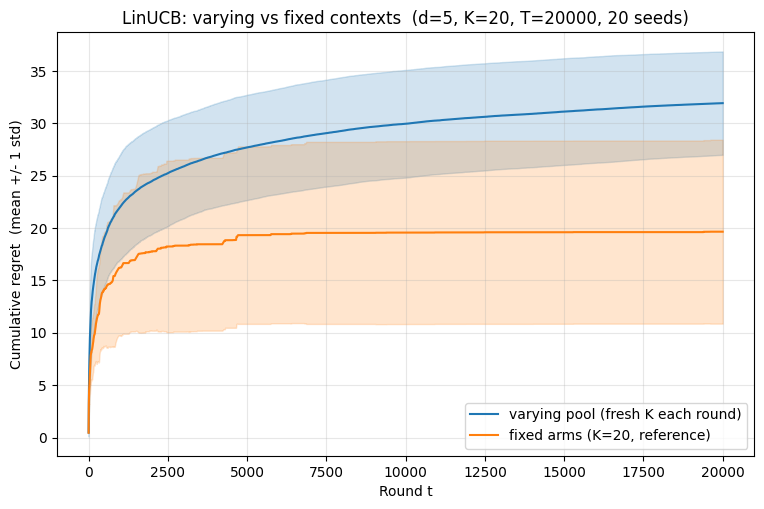

In [18]:
# === Task 4, Part A: LinUCB regret under varying contexts ===
T = 20000
n_seeds = 20

vary_reg, _ = run_experiment(linucb, env_factory_varying, T, n_seeds)
fixed_reg, _ = run_experiment(linucb, env_factory_fixed20, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_averaged_regret(vary_reg, "varying pool (fresh K each round)", ax)
plot_averaged_regret(fixed_reg, f"fixed arms (K={K_POOL}, reference)", ax)
ax.set_title(f"LinUCB: varying vs fixed contexts  (d={D_FIX}, K={K_POOL}, T={T}, {n_seeds} seeds)")
plt.show()


**Write-up (TODO) -- 1 mark.**

Is LinUCB's regret still sublinear (does the curve bend over) when the pool changes every round? Explain why a changing arm set does not break the algorithm, given that what it estimates is $\theta$, not a value per arm. You may also comment on how the varying-pool curve compares to the fixed-arm reference and why the two need not match.

*(TODO: write your observations below.)*


**Observations**: 

LinUCB focuses on estimating environment $\theta$, not a value per arm as in vanilla UCB. So even though arms change every round, underlying environment remains the same due to which LinUCB is able to achieve sublinear regret. Its regret bound $O(d \sqrt{T})$ also is independent of number of arms $K$, enabling LinUCB to adapt even when number of arms $K$ changes.

However in fixed-arms environment, LinUCB is able to effectively identify and stop exploring suboptimal arms to limit regret. But in varying-pool, LinUCB is forced to keep exploring new arms introduced, especially if they are in an un-explored area of feature space. This increases rate of regret growth and reduces uncertainity.



### Part B -- no single best arm *(1 mark)*

A fixed-arm intuition says "find the best arm and pull it forever". Here the best arm is a different feature vector each round. The left panel below shows the best available mean fluctuating round to round; the right panel tracks the rolling-average instantaneous regret of LinUCB, to see whether it nonetheless picks near-best arms as it learns.


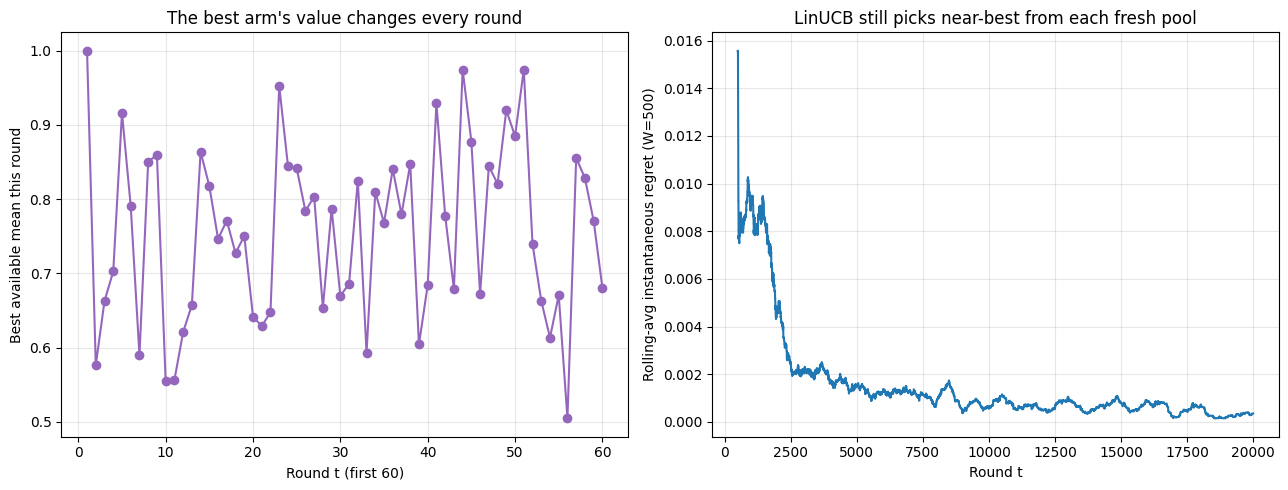

In [19]:
# === Task 4, Part B: there is no fixed best arm to lock onto ===
T = 20000
env_v = env_factory_varying(np.random.default_rng(BASE_SEED))
arms_seq, reg_seq = linucb(env_v, T, beta=1.0)

# Rolling-average instantaneous regret (window W).
W = 500
roll = np.convolve(reg_seq, np.ones(W) / W, mode="valid")

# Separate illustrative draw: the best available mean over the first 60 rounds.
env_show = env_factory_varying(np.random.default_rng(BASE_SEED))
best_means = []
for _ in range(60):
    X = env_show.new_round()
    best_means.append(float((X @ theta_star).max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(np.arange(1, 61), best_means, "o-", color="#9467bd")
axes[0].set_xlabel("Round t (first 60)")
axes[0].set_ylabel("Best available mean this round")
axes[0].set_title("The best arm's value changes every round")

axes[1].plot(np.arange(W, T + 1), roll, color="#1f77b4")
axes[1].set_xlabel("Round t")
axes[1].set_ylabel(f"Rolling-avg instantaneous regret (W={W})")
axes[1].set_title("LinUCB still picks near-best from each fresh pool")

plt.tight_layout()
plt.show()


**Write-up (TODO) -- 1 mark.**

The left panel shows the best achievable mean is different each round, so "pull one fixed arm forever" is not even well defined here. Yet the right panel's rolling regret decreases. Explain how LinUCB can do well without a fixed target: what is the thing it gets better at over time, and how does that let it pick a good arm from a pool it has never seen before?

*(TODO: write your observations below.)*


LinUCB gets better at estimating environment $\theta$ over time. Even though arms change every round, it is able to combine environment $\theta$ and arms' context vectors $x_{t,a}$ to calculate estimated arms' rewards as linear dot product of the two. So it gets better at estimating rewards, from which it is able to better identify best arm each round from varying pool.

### Part C -- estimation: varying vs fixed contexts *(1 mark)*

We compare how fast $\hat\theta_t$ approaches $\theta$ under the two regimes, at the same dimension $d = 5$. We run LinUCB once in each and plot $\lVert \hat\theta_t - \theta\rVert_2$ over time (log scale).


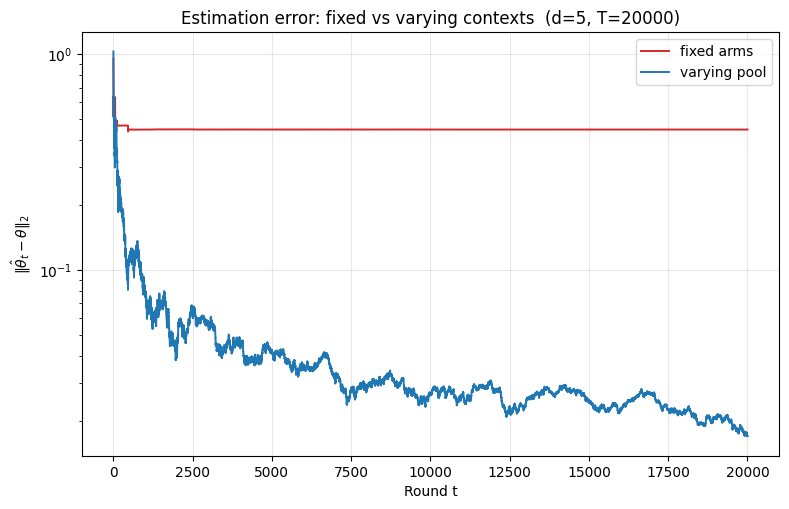

In [20]:
# === Task 4, Part C: estimation error, varying vs fixed ===
T = 20000
# Same K=20 fixed reference as Part A.
env_fix = env_factory_fixed20(np.random.default_rng(BASE_SEED + 5))
env_var = env_factory_varying(np.random.default_rng(BASE_SEED + 5))

_, _, tr_fix = linucb(env_fix, T, beta=1.0, return_trace=True)
_, _, tr_var = linucb(env_var, T, beta=1.0, return_trace=True)

err_fix = np.linalg.norm(tr_fix["theta_hat"] - theta_star, axis=1)
err_var = np.linalg.norm(tr_var["theta_hat"] - theta_star, axis=1)
tt = np.arange(1, T + 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(tt, err_fix, label="fixed arms", color="#d62728", lw=1.4)
ax.plot(tt, err_var, label="varying pool", color="#1f77b4", lw=1.4)
ax.set_xlabel("Round t")
ax.set_ylabel(r"$\|\hat\theta_t - \theta\|_2$")
ax.set_title(f"Estimation error: fixed vs varying contexts  (d={D_FIX}, T={T})")
ax.set_yscale("log")
ax.legend()
plt.show()


**Write-up (TODO) -- 1 mark.**

Which regime drives $\lVert \hat\theta_t - \theta\rVert$ down faster, fixed or varying contexts? Connect this to Task 2 Part A: the error shrinks fastest in the feature directions that get pulled most, i.e. the directions where $V_t$'s eigenvalues grow. With a fresh random pool each round, pulls are spread over many directions; with fixed arms, LinUCB concentrates on a few good arms. Use that to explain the gap between the two curves.

*(TODO: write your observations below.)*


**Observation**: In fixed arms, LinUCB concentrates on a few good arms - confidence ellipsoid shrinks fast in the corresponding axes, and stays almost constant in other un-explored axes. So after a point estimation error distance of $\theta$ becomes constant due to un-explored arms. On the other hand, with a varying arm pool, LinUCB is forced to explore arm pulls in all directions, which shrinks confidence ellipsoid in all directions and shrinks error (distance from true $\theta$).

---

## Bonus -- cold start (optional, scaffolded)

This part is optional and adds to your total. It isolates one consequence of sharing $\theta$: how a brand-new arm is treated. The experiment is provided in full; you only need to run it and comment.

Setup: a fixed catalogue of articles is shown to LinUCB for a warm-up period, building up $V$. Then a *new* article arrives. Its exploration bonus is $\beta\lVert x_{\text{new}}\rVert_{V^{-1}}$, which depends on the *direction* of its features relative to what has already been explored. We compare two new articles -- one whose features lie in a well-explored direction, one in a poorly-explored direction -- and contrast both with vanilla UCB, which has no features and so treats every new article identically.


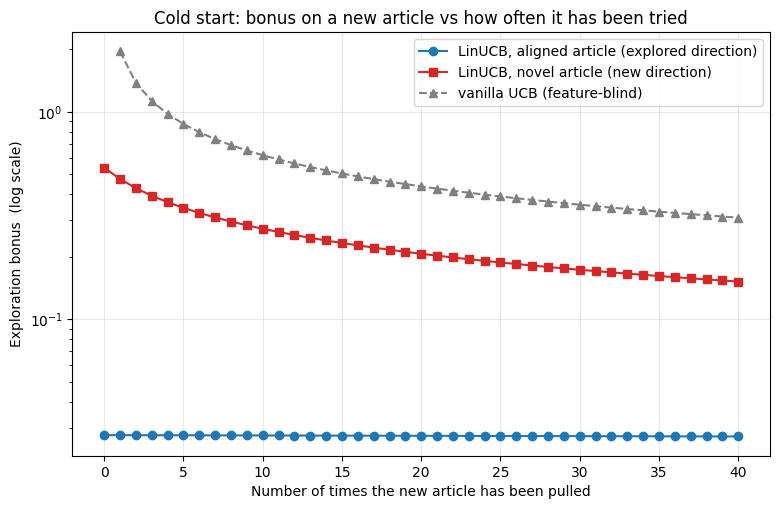

At 0 pulls: aligned bonus = 0.028, novel bonus = 0.537


In [21]:
# === Bonus: cold start -- warm vs novel new article ===
T_warm = 2000
d_b = 5

# A fixed catalogue of 30 articles; warm up LinUCB on it to build V.
catalog_rng = np.random.default_rng(BASE_SEED + 7)
theta_b = unit_rows(catalog_rng, 1, d_b)[0]
catalog = unit_rows(catalog_rng, 30, d_b)
env_b = LinearBandit(theta_b, catalog, sigma=SIGMA, rng=np.random.default_rng(BASE_SEED + 8))
_, _, tr_b = linucb(env_b, T_warm, beta=1.0, return_trace=True)
V_warm = tr_b["V"][-1]                          # V after the warm-up period

# Two candidate new articles, taken from the eigen-directions of V_warm:
#   - aligned: the most-explored direction (largest eigenvalue) -> small bonus
#   - novel  : the least-explored direction (smallest eigenvalue) -> large bonus
vals, vecs = np.linalg.eigh(V_warm)
x_aligned = vecs[:, -1]
x_novel = vecs[:, 0]

def bonus_curve(x_new, V_start, beta=1.0, n_pulls=40):
    """Exploration bonus beta * ||x_new||_{V^{-1}} as the new article is pulled repeatedly."""
    V = V_start.copy()
    out = []
    for _ in range(n_pulls + 1):
        Vinv = np.linalg.inv(V)
        out.append(beta * np.sqrt(x_new @ Vinv @ x_new))
        V = V + np.outer(x_new, x_new)          # one more pull of the new article
    return np.array(out)

n_pulls = 40
b_aligned = bonus_curve(x_aligned, V_warm, n_pulls=n_pulls)
b_novel = bonus_curve(x_novel, V_warm, n_pulls=n_pulls)

# Vanilla UCB is feature-blind: its bonus after n pulls is sigma * sqrt(2 log T / n),
# the same whatever the article's features are. Undefined at n = 0, so we NaN
# that point out (its first finite value is at n = 1).
n_axis = np.arange(0, n_pulls + 1)
with np.errstate(divide="ignore"):
    ucb_blind = SIGMA * np.sqrt(2 * np.log(T_warm) / n_axis)
ucb_blind[0] = np.nan

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_axis, b_aligned, "o-", color="#1f77b4",
        label="LinUCB, aligned article (explored direction)")
ax.plot(n_axis, b_novel, "s-", color="#d62728",
        label="LinUCB, novel article (new direction)")
ax.plot(n_axis, ucb_blind, "^--", color="gray", label="vanilla UCB (feature-blind)")
ax.set_xlabel("Number of times the new article has been pulled")
ax.set_ylabel("Exploration bonus  (log scale)")
ax.set_title("Cold start: bonus on a new article vs how often it has been tried")
ax.set_yscale("log")   # the three bonuses span ~2 orders of magnitude (about 0.03 to 2)
ax.legend()
plt.show()

print(f"At 0 pulls: aligned bonus = {b_aligned[0]:.3f}, novel bonus = {b_novel[0]:.3f}")


**Write-up (TODO) -- bonus.**

At zero pulls, the aligned article already has a small bonus while the novel one has a large bonus. LinUCB inherits an estimate for the aligned article from everything it learned during warm-up, and barely needs to explore it; the novel article points in a direction $V$ knows little about, so its bonus is large. Vanilla UCB, having no features, assigns the same (maximal) uncertainty to any new article and must pull it from scratch regardless of how much it resembles articles already seen. Explain how this follows from the bonus $\beta\lVert x_{\text{new}}\rVert_{V^{-1}}$, and what it implies for a system where new items arrive constantly.

*(TODO: write your observations below.)*


**Observation**: Exploration bonus is $\beta\lVert x_{\text{new}}\rVert_{V^{-1}}$. For the new aligned article, LinUCB has already explored many nearby vectors. So its eigenvalues along the axis are already large. Confdence ellipsoid radius is small (due to inversely proportionality to square root of eigenvalue), so the new aligned article does not need to be pulled much. But the novel article's context vector is along an unexplored axis, so it starts off with a high exploration bonus.
This implies that LinUCB can handle a system (like news recommendation) where new items arrive constantly (as it spends time exploring only novel articles), unlike vanilla UCB which has to maximally explore all new articles.